In [1]:
import pandas as pd

df = pd.read_csv('hsls_clean_trad.csv')

print("X4EVERDROP vs X4EVERGED — Full Sample")
print(pd.crosstab(df['X4EVERDROP'], df['X4EVERGED'], margins=True))
print()
print("Row proportions:")
print(pd.crosstab(df['X4EVERDROP'], df['X4EVERGED'], normalize='index').round(3))

X4EVERDROP vs X4EVERGED — Full Sample
X4EVERGED       0    1    All
X4EVERDROP                   
0           13454    4  13458
1            1700  660   2360
All         15154  664  15818

Row proportions:
X4EVERGED      0     1
X4EVERDROP            
0           1.00  0.00
1           0.72  0.28


In [2]:
print("Target: X4EVERDROP (Any Dropout)")
print(df['X4EVERDROP'].value_counts().sort_index())
print(f"Total: {len(df)}")
print()
print("Target: X4EVERDROP_TRAD (Traditional Dropout Only)")
print(df['X4EVERDROP_TRAD'].value_counts().sort_index())
print(f"Total: {len(df)}")

Target: X4EVERDROP (Any Dropout)
X4EVERDROP
0    13458
1     2360
Name: count, dtype: int64
Total: 15818

Target: X4EVERDROP_TRAD (Traditional Dropout Only)
X4EVERDROP_TRAD
0    14118
1     1700
Name: count, dtype: int64
Total: 15818


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

# Load models
tier1_fine_search = joblib.load('tier1_fine_search.pkl')
tier2_fine_search = joblib.load('tier2_fine_search.pkl')
tier3_fine_search = joblib.load('tier3_fine_search.pkl')
tier4_fine_search = joblib.load('tier4_fine_search.pkl')

# Load data
X_train_tier1, y_train_tier1, X_test_tier1, y_test_tier1 = joblib.load('data_tier1.pkl')
X_train_tier2, y_train_tier2, X_test_tier2, y_test_tier2 = joblib.load('data_tier2.pkl')
X_train_tier3, y_train_tier3, X_test_tier3, y_test_tier3 = joblib.load('data_tier3.pkl')
X_train_tier4, y_train_tier4, X_test_tier4, y_test_tier4 = joblib.load('data_tier4.pkl')

# Load traditional dropout models
tier1_fine_search_trad = joblib.load('tier1_fine_search_trad.pkl')
tier2_fine_search_trad = joblib.load('tier2_fine_search_trad.pkl')
tier3_fine_search_trad = joblib.load('tier3_fine_search_trad.pkl')
tier4_fine_search_trad = joblib.load('tier4_fine_search_trad.pkl')

X_train_tier1_trad, y_train_tier1_trad, X_test_tier1_trad, y_test_tier1_trad = joblib.load('data_tier1_trad.pkl')
X_train_tier2_trad, y_train_tier2_trad, X_test_tier2_trad, y_test_tier2_trad = joblib.load('data_tier2_trad.pkl')
X_train_tier3_trad, y_train_tier3_trad, X_test_tier3_trad, y_test_tier3_trad = joblib.load('data_tier3_trad.pkl')
X_train_tier4_trad, y_train_tier4_trad, X_test_tier4_trad, y_test_tier4_trad = joblib.load('data_tier4_trad.pkl')

print("All loaded successfully.")

All loaded successfully.


In [5]:
import joblib
import pandas as pd

tier4_fine_search = joblib.load('tier4_fine_search.pkl')

results = pd.DataFrame(tier4_fine_search.cv_results_)
param_cols = [col for col in results.columns if col.startswith('param_')]
metric_cols = ['mean_test_f1', 'mean_test_precision', 'mean_test_recall', 'mean_test_roc_auc']

df_results = results[param_cols + metric_cols].copy()
df_results.columns = [c.replace('param_', '').replace('mean_test_', '') for c in df_results.columns]

# Filter and sort
min_f1 = 0.5
filtered = df_results[df_results['f1'] >= min_f1].sort_values('recall', ascending=False)

print(f"Models with F1 >= {min_f1}: {len(filtered)}")
print(filtered.to_string(index=False))

Models with F1 >= 0.5: 852
 colsample_bytree  learning_rate  max_depth  n_estimators  subsample       f1  precision   recall  roc_auc
              0.7          0.010          3           200        0.9 0.501952   0.372256 0.770659 0.853480
              0.7          0.010          3           200        0.8 0.504062   0.374832 0.769601 0.854244
              0.8          0.005          3           300        0.7 0.501428   0.371945 0.769600 0.851594
              0.7          0.005          4           200        0.7 0.503365   0.374164 0.769078 0.853024
              0.7          0.010          3           300        0.9 0.512504   0.384426 0.769078 0.857965
              0.7          0.010          3           200        1.0 0.500514   0.371040 0.769072 0.853131
              0.7          0.005          4           200        0.8 0.500969   0.371669 0.768546 0.852384
              0.7          0.010          3           300        0.7 0.512810   0.384875 0.768542 0.858454
          

In [6]:
tier4_fine_search = joblib.load('tier4_fine_search.pkl')

results = pd.DataFrame(tier4_fine_search.cv_results_)
param_cols = [col for col in results.columns if col.startswith('param_')]
metric_cols = ['mean_test_f1', 'mean_test_precision', 'mean_test_recall', 'mean_test_roc_auc']

df_results = results[param_cols + metric_cols].copy()
df_results.columns = [c.replace('param_', '').replace('mean_test_', '') for c in df_results.columns]

# Filter and sort
min_f1 = 0.5
filtered = df_results[df_results['f1'] >= min_f1].sort_values('precision', ascending=False)

print(f"Models with F1 >= {min_f1}: {len(filtered)}")
print(filtered.to_string(index=False))

Models with F1 >= 0.5: 852
 colsample_bytree  learning_rate  max_depth  n_estimators  subsample       f1  precision   recall  roc_auc
              0.7          0.100          5          1000        0.9 0.501966   0.643163 0.412061 0.843469
              0.8          0.100          5          1000        0.9 0.501292   0.635602 0.414210 0.843819
              0.7          0.100          5          1000        0.7 0.505870   0.634815 0.420555 0.841776
              0.7          0.100          5           750        0.9 0.509758   0.630921 0.427958 0.843572
              0.8          0.100          5          1000        1.0 0.502649   0.629756 0.418429 0.842546
              0.7          0.100          5          1000        1.0 0.503480   0.627924 0.420548 0.841062
              0.8          0.100          5           750        0.9 0.511297   0.626184 0.432209 0.843715
              0.7          0.100          5           750        1.0 0.512274   0.623014 0.435374 0.840861
          

In [7]:
# Load all models
models = {
    'any_tier1': joblib.load('tier1_fine_search.pkl'),
    'any_tier2': joblib.load('tier2_fine_search.pkl'),
    'any_tier3': joblib.load('tier3_fine_search.pkl'),
    'any_tier4': joblib.load('tier4_fine_search.pkl'),
    'trad_tier1': joblib.load('tier1_fine_search_trad.pkl'),
    'trad_tier2': joblib.load('tier2_fine_search_trad.pkl'),
    'trad_tier3': joblib.load('tier3_fine_search_trad.pkl'),
    'trad_tier4': joblib.load('tier4_fine_search_trad.pkl'),
}

param_cols_clean = ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']
metric_cols = ['mean_test_f1', 'mean_test_precision', 'mean_test_recall', 'mean_test_roc_auc']

for name, model in models.items():
    results = pd.DataFrame(model.cv_results_)
    param_cols = [col for col in results.columns if col.startswith('param_')]
    df_results = results[param_cols + metric_cols].copy()
    df_results.columns = param_cols_clean + [c.replace('mean_test_', '') for c in metric_cols]
    
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"\nTop 5 by Recall:")
    print(df_results.nlargest(5, 'recall')[['recall', 'precision', 'f1'] + param_cols_clean].to_string(index=False))
    print(f"\nTop 5 by Precision:")
    print(df_results.nlargest(5, 'precision')[['precision', 'recall', 'f1'] + param_cols_clean].to_string(index=False))


Model: any_tier1

Top 5 by Recall:
  recall  precision       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.728802   0.375899 0.495909           0.5      0.005              6        300               0.9
0.726153   0.377345 0.496542           0.5      0.005              6        300               0.8
0.720326   0.383532 0.500450           0.5      0.005              6        300               0.6
0.719267   0.378064 0.495569           0.6      0.005              6        300               0.9
0.718736   0.376128 0.493741           0.5      0.005              6        300               0.7

Top 5 by Precision:
 precision   recall       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
  0.608393 0.378701 0.466740           0.9       0.05             10       1000               0.7
  0.607366 0.385060 0.471221           0.9       0.05             10        750               0.7
  0.605852 0.385050 0.470746           0.8       0.05        

In [8]:
for name, model in models.items():
    results = pd.DataFrame(model.cv_results_)
    param_cols = [col for col in results.columns if col.startswith('param_')]
    df_results = results[param_cols + metric_cols].copy()
    df_results.columns = param_cols_clean + [c.replace('mean_test_', '') for c in metric_cols]
    
    filtered = df_results[df_results['f1'] >= 0.5]
    
    print(f"\n{'='*60}")
    print(f"Model: {name} — {len(filtered)} combinations with F1 >= 0.5")
    
    print(f"\nTop 5 by Recall (F1 >= 0.5):")
    print(filtered.nlargest(5, 'recall')[['recall', 'precision', 'f1'] + param_cols_clean].to_string(index=False))
    
    print(f"\nTop 5 by Precision (F1 >= 0.5):")
    print(filtered.nlargest(5, 'precision')[['precision', 'recall', 'f1'] + param_cols_clean].to_string(index=False))


Model: any_tier1 — 731 combinations with F1 >= 0.5

Top 5 by Recall (F1 >= 0.5):
  recall  precision       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.720326   0.383532 0.500450           0.5      0.005              6        300               0.6
0.718208   0.384408 0.500708           0.5      0.005              6        500               0.9
0.714506   0.385765 0.500969           0.5      0.005              6        500               0.8
0.711851   0.388251 0.502394           0.5      0.010              6        300               0.8
0.711322   0.386833 0.501076           0.9      0.005              6        500               0.9

Top 5 by Precision (F1 >= 0.5):
 precision   recall       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
  0.546030 0.461847 0.500228           0.5       0.01             10        750               0.9
  0.545000 0.468202 0.503469           0.9       0.01             10        750               0.7
  0

In [10]:
for name, model in models.items():
    results = pd.DataFrame(model.cv_results_)
    param_cols = [col for col in results.columns if col.startswith('param_')]
    df_results = results[param_cols + metric_cols].copy()
    df_results.columns = param_cols_clean + [c.replace('mean_test_', '') for c in metric_cols]
    
    filtered = df_results[df_results['f1'] >= 0.0]
    
    print(f"\n{'='*60}")
    print(f"Model: {name} — {len(filtered)} combinations with F1 >= 0.0")
    
    print(f"\nTop 5 by Recall (F1 >= 0.0):")
    print(filtered.nlargest(5, 'recall')[['recall', 'precision', 'f1'] + param_cols_clean].to_string(index=False))
    
    print(f"\nTop 5 by Precision (F1 >= 0.0):")
    print(filtered.nlargest(5, 'precision')[['precision', 'recall', 'f1'] + param_cols_clean].to_string(index=False))


Model: any_tier1 — 1152 combinations with F1 >= 0.0

Top 5 by Recall (F1 >= 0.0):
  recall  precision       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.728802   0.375899 0.495909           0.5      0.005              6        300               0.9
0.726153   0.377345 0.496542           0.5      0.005              6        300               0.8
0.720326   0.383532 0.500450           0.5      0.005              6        300               0.6
0.719267   0.378064 0.495569           0.6      0.005              6        300               0.9
0.718736   0.376128 0.493741           0.5      0.005              6        300               0.7

Top 5 by Precision (F1 >= 0.0):
 precision   recall       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
  0.608393 0.378701 0.466740           0.9       0.05             10       1000               0.7
  0.607366 0.385060 0.471221           0.9       0.05             10        750               0.7
  

In [11]:
for name, model in models.items():
    if 'trad' in name:
        continue
        
    results = pd.DataFrame(model.cv_results_)
    param_cols = [col for col in results.columns if col.startswith('param_')]
    df_results = results[param_cols + metric_cols].copy()
    df_results.columns = param_cols_clean + [c.replace('mean_test_', '') for c in metric_cols]
    
    filtered = df_results[df_results['f1'] >= 0.5]
    
    print(f"\n{'='*60}")
    print(f"Model: {name} — {len(filtered)} combinations with F1 >= 0.5")
    
    best_recall = filtered.nlargest(1, 'recall')[['recall', 'precision', 'f1'] + param_cols_clean]
    best_precision = filtered.nlargest(1, 'precision')[['precision', 'recall', 'f1'] + param_cols_clean]
    
    print(f"\nHighest Recall:    {best_recall.to_string(index=False)}")
    print(f"Highest Precision: {best_precision.to_string(index=False)}")


Model: any_tier1 — 731 combinations with F1 >= 0.5

Highest Recall:      recall  precision      f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.720326   0.383532 0.50045           0.5      0.005              6        300               0.6
Highest Precision:  precision   recall       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
   0.54603 0.461847 0.500228           0.5       0.01             10        750               0.9

Model: any_tier2 — 1432 combinations with F1 >= 0.5

Highest Recall:      recall  precision       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.722459   0.383142 0.500643           0.6       0.01              6        200               0.8
Highest Precision:  precision   recall       f1  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
  0.624445 0.417352 0.500084           0.6       0.01             15        750               0.7

Model: any_tier3 — 1071 combinatio

In [13]:
for name, model in models.items():
    if 'trad' in name:
        continue
        
    results = pd.DataFrame(model.cv_results_)
    param_cols = [col for col in results.columns if col.startswith('param_')]
    df_results = results[param_cols + metric_cols].copy()
    df_results.columns = param_cols_clean + [c.replace('mean_test_', '') for c in metric_cols]
    
    filtered = df_results[df_results['f1'] >= 0.5]
    
    print(f"\n{'='*60}")
    print(f"Model: {name} — {len(filtered)} combinations with F1 >= 0.5")
    
    best_recall = filtered.nlargest(1, 'recall')[['recall', 'precision', 'f1'] + param_cols_clean]
    best_precision = filtered.nlargest(1, 'precision')[['precision', 'recall', 'f1'] + param_cols_clean]
    best_f1 = filtered.nlargest(1, 'f1')[['f1', 'precision', 'recall'] + param_cols_clean]
    
    print(f"Highest F1:        {best_f1.to_string(index=False)}")


Model: any_tier1 — 731 combinations with F1 >= 0.5
Highest F1:              f1  precision   recall  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.520715   0.445003 0.627637           0.8      0.005              8        750               0.6

Model: any_tier2 — 1432 combinations with F1 >= 0.5
Highest F1:             f1  precision   recall  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.52256   0.477105 0.577851           0.8       0.01              7       1000               0.6

Model: any_tier3 — 1071 combinations with F1 >= 0.5
Highest F1:              f1  precision   recall  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.545758   0.474464 0.642466           0.7      0.005              7       1000               0.9

Model: any_tier4 — 852 combinations with F1 >= 0.5
Highest F1:              f1  precision   recall  n_estimators  max_depth  learning_rate  subsample  colsample_bytree
0.549883     0.4788 0.646189  

Tier 1 — Best threshold: 0.542, Best F1: 0.5468
Tier 2 — Best threshold: 0.521, Best F1: 0.5460
Tier 3 — Best threshold: 0.593, Best F1: 0.5699
Tier 4 — Best threshold: 0.572, Best F1: 0.5720


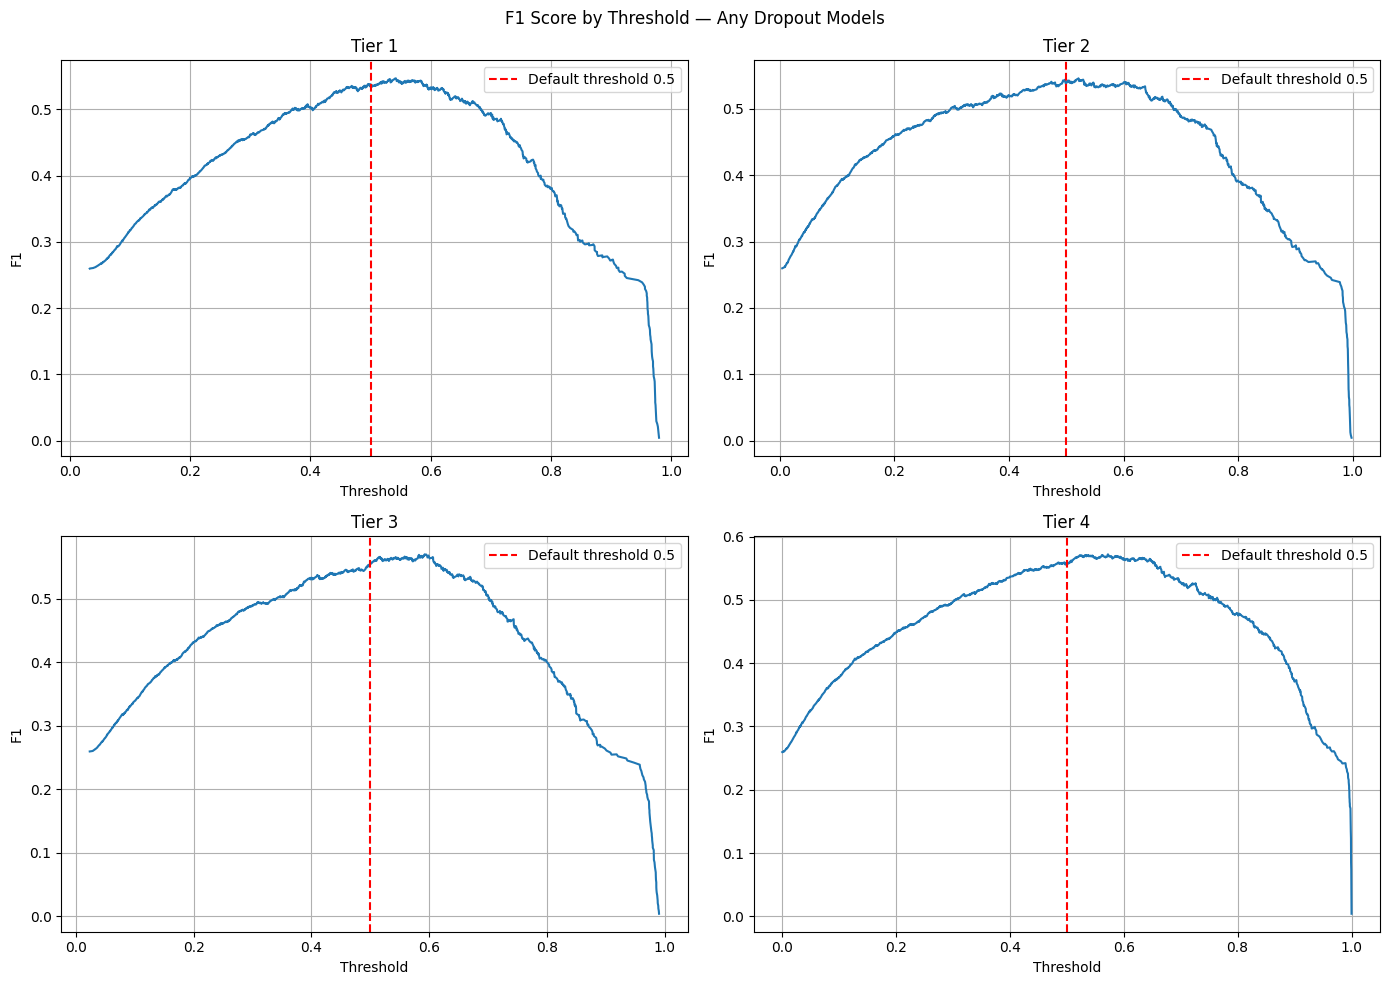

In [17]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (tier, fine_search, X_test, y_test) in enumerate([
    (1, tier1_fine_search, X_test_tier1, y_test_tier1),
    (2, tier2_fine_search, X_test_tier2, y_test_tier2),
    (3, tier3_fine_search, X_test_tier3, y_test_tier3),
    (4, tier4_fine_search, X_test_tier4, y_test_tier4),
]):
    model = fine_search.best_estimator_
    y_prob = model.predict_proba(X_test)[:, 1]
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    
    # Compute F1 for each threshold
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
    
    axes[i].plot(thresholds, f1_scores)
    axes[i].axvline(x=0.5, color='red', linestyle='--', label='Default threshold 0.5')
    axes[i].set_title(f'Tier {tier}')
    axes[i].set_xlabel('Threshold')
    axes[i].set_ylabel('F1')
    axes[i].legend()
    axes[i].grid(True)
    
    best_threshold = thresholds[np.argmax(f1_scores)]
    best_f1 = f1_scores.max()
    print(f"Tier {tier} — Best threshold: {best_threshold:.3f}, Best F1: {best_f1:.4f}")

plt.suptitle('F1 Score by Threshold — Any Dropout Models')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import precision_recall_curve
import numpy as np

for tier, fine_search, X_test, y_test in [
    (1, tier1_fine_search, X_test_tier1, y_test_tier1),
    (2, tier2_fine_search, X_test_tier2, y_test_tier2),
    (3, tier3_fine_search, X_test_tier3, y_test_tier3),
    (4, tier4_fine_search, X_test_tier4, y_test_tier4),
]:
    model = fine_search.best_estimator_
    y_prob = model.predict_proba(X_test)[:, 1]
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
    
    best_idx = np.argmax(f1_scores)
    
    print(f"Tier {tier}:")
    print(f"  Best threshold: {thresholds[best_idx]:.4f}")
    print(f"  F1:             {f1_scores[best_idx]:.4f}")
    print(f"  Precision:      {precisions[best_idx]:.4f}")
    print(f"  Recall:         {recalls[best_idx]:.4f}")
    print()

Tier 1:
  Best threshold: 0.5419
  F1:             0.5468
  Precision:      0.4983
  Recall:         0.6059

Tier 2:
  Best threshold: 0.5211
  F1:             0.5460
  Precision:      0.5027
  Recall:         0.5975

Tier 3:
  Best threshold: 0.5925
  F1:             0.5699
  Precision:      0.5831
  Recall:         0.5572

Tier 4:
  Best threshold: 0.5725
  F1:             0.5720
  Precision:      0.5319
  Recall:         0.6186



In [20]:
import xgboost as xgb
import joblib

X_train_tier1, y_train_tier1, X_test_tier1, y_test_tier1 = joblib.load('data_tier1.pkl')

model_best_recall = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.005,
    subsample=0.6, colsample_bytree=0.6,
    scale_pos_weight=y_train_tier1.value_counts()[0] / y_train_tier1.value_counts()[1],
    random_state=42, eval_metric='logloss'
)

model_best_precision = xgb.XGBClassifier(
    n_estimators=750, max_depth=10, learning_rate=0.01,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=y_train_tier1.value_counts()[0] / y_train_tier1.value_counts()[1],
    random_state=42, eval_metric='logloss'
)

model_best_f1 = xgb.XGBClassifier(
    n_estimators=750, max_depth=8, learning_rate=0.005,
    subsample=0.8, colsample_bytree=0.6,
    scale_pos_weight=y_train_tier1.value_counts()[0] / y_train_tier1.value_counts()[1],
    random_state=42, eval_metric='logloss'
)

model_best_recall.fit(X_train_tier1, y_train_tier1)
model_best_precision.fit(X_train_tier1, y_train_tier1)
model_best_f1.fit(X_train_tier1, y_train_tier1)

print("All three models fitted")

joblib.dump(model_best_recall,    'tier1_recall_model.pkl')
joblib.dump(model_best_precision, 'tier1_precision_model.pkl')
joblib.dump(model_best_f1,        'tier1_f1_model.pkl')

print("Saved to pkl")

All three models fitted
Saved to pkl
